<a href="https://colab.research.google.com/github/vanemn/eda-mercado-inmobiliario/blob/main/kpi_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 KPI Operations Dashboard
### Monitor Interactivo de KPIs Operativos y Financieros para Gestión de Proyectos

**Autora:** Vanessa Morales Norambuena  
**Stack:** Python · Pandas · Matplotlib · Plotly  
**Contexto:** Basado en metodologías de control de proyectos aplicadas en entornos de construcción e inmobiliario

---
## Objetivo
Diseñar un sistema de monitorización de KPIs operativos y financieros que permita detectar desviaciones en proyectos de forma temprana y tomar decisiones basadas en datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

C1, C2, C3, C4 = '#1A3A5C', '#1A7A5C', '#E76F51', '#F4A261'
print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
np.random.seed(7)
meses = pd.date_range('2024-01', periods=12, freq='ME')
proyectos = ['Proyecto Alpha', 'Proyecto Beta', 'Proyecto Gamma', 'Proyecto Delta']

# KPIs financieros mensuales (empresa)
df_financiero = pd.DataFrame({
    'mes': meses,
    'presupuesto': [850, 920, 880, 960, 1050, 1100, 1080, 1150, 1200, 1180, 1250, 1300],
    'ejecutado': [820, 890, 910, 940, 1010, 1140, 1050, 1180, 1160, 1220, 1210, 1280],
    'ingresos': [900, 950, 940, 1020, 1100, 1150, 1120, 1220, 1280, 1250, 1320, 1400],
    'margen_objetivo': [8.5]*12
})
df_financiero['desviacion_pct'] = ((df_financiero['ejecutado'] - df_financiero['presupuesto']) / df_financiero['presupuesto'] * 100).round(1)
df_financiero['margen_real'] = ((df_financiero['ingresos'] - df_financiero['ejecutado']) / df_financiero['ingresos'] * 100).round(1)

# KPIs por proyecto
df_proyectos = pd.DataFrame({
    'proyecto': proyectos,
    'avance_planificado': [100, 75, 45, 20],
    'avance_real': [98, 71, 50, 18],
    'presupuesto_total': [2400, 1800, 3200, 900],
    'gasto_actual': [2350, 1420, 1680, 145],
    'plazo_dias_plan': [365, 280, 420, 180],
    'plazo_dias_real': [368, 295, 415, 185],
    'satisfaccion_cliente': [4.5, 4.2, 4.7, 4.0],
    'incidencias_abiertas': [2, 5, 1, 3]
})
df_proyectos['burn_rate'] = (df_proyectos['gasto_actual'] / df_proyectos['presupuesto_total'] * 100).round(1)
df_proyectos['spi'] = (df_proyectos['avance_real'] / df_proyectos['avance_planificado']).round(2)  # Schedule Performance Index

print('✅ Datos generados')
df_proyectos[['proyecto','avance_real','burn_rate','spi','satisfaccion_cliente']].to_string(index=False)

✅ Datos generados


'      proyecto  avance_real  burn_rate  spi  satisfaccion_cliente\nProyecto Alpha           98       97.9 0.98                   4.5\n Proyecto Beta           71       78.9 0.95                   4.2\nProyecto Gamma           50       52.5 1.11                   4.7\nProyecto Delta           18       16.1 0.90                   4.0'

## Dashboard Ejecutivo — Vista General

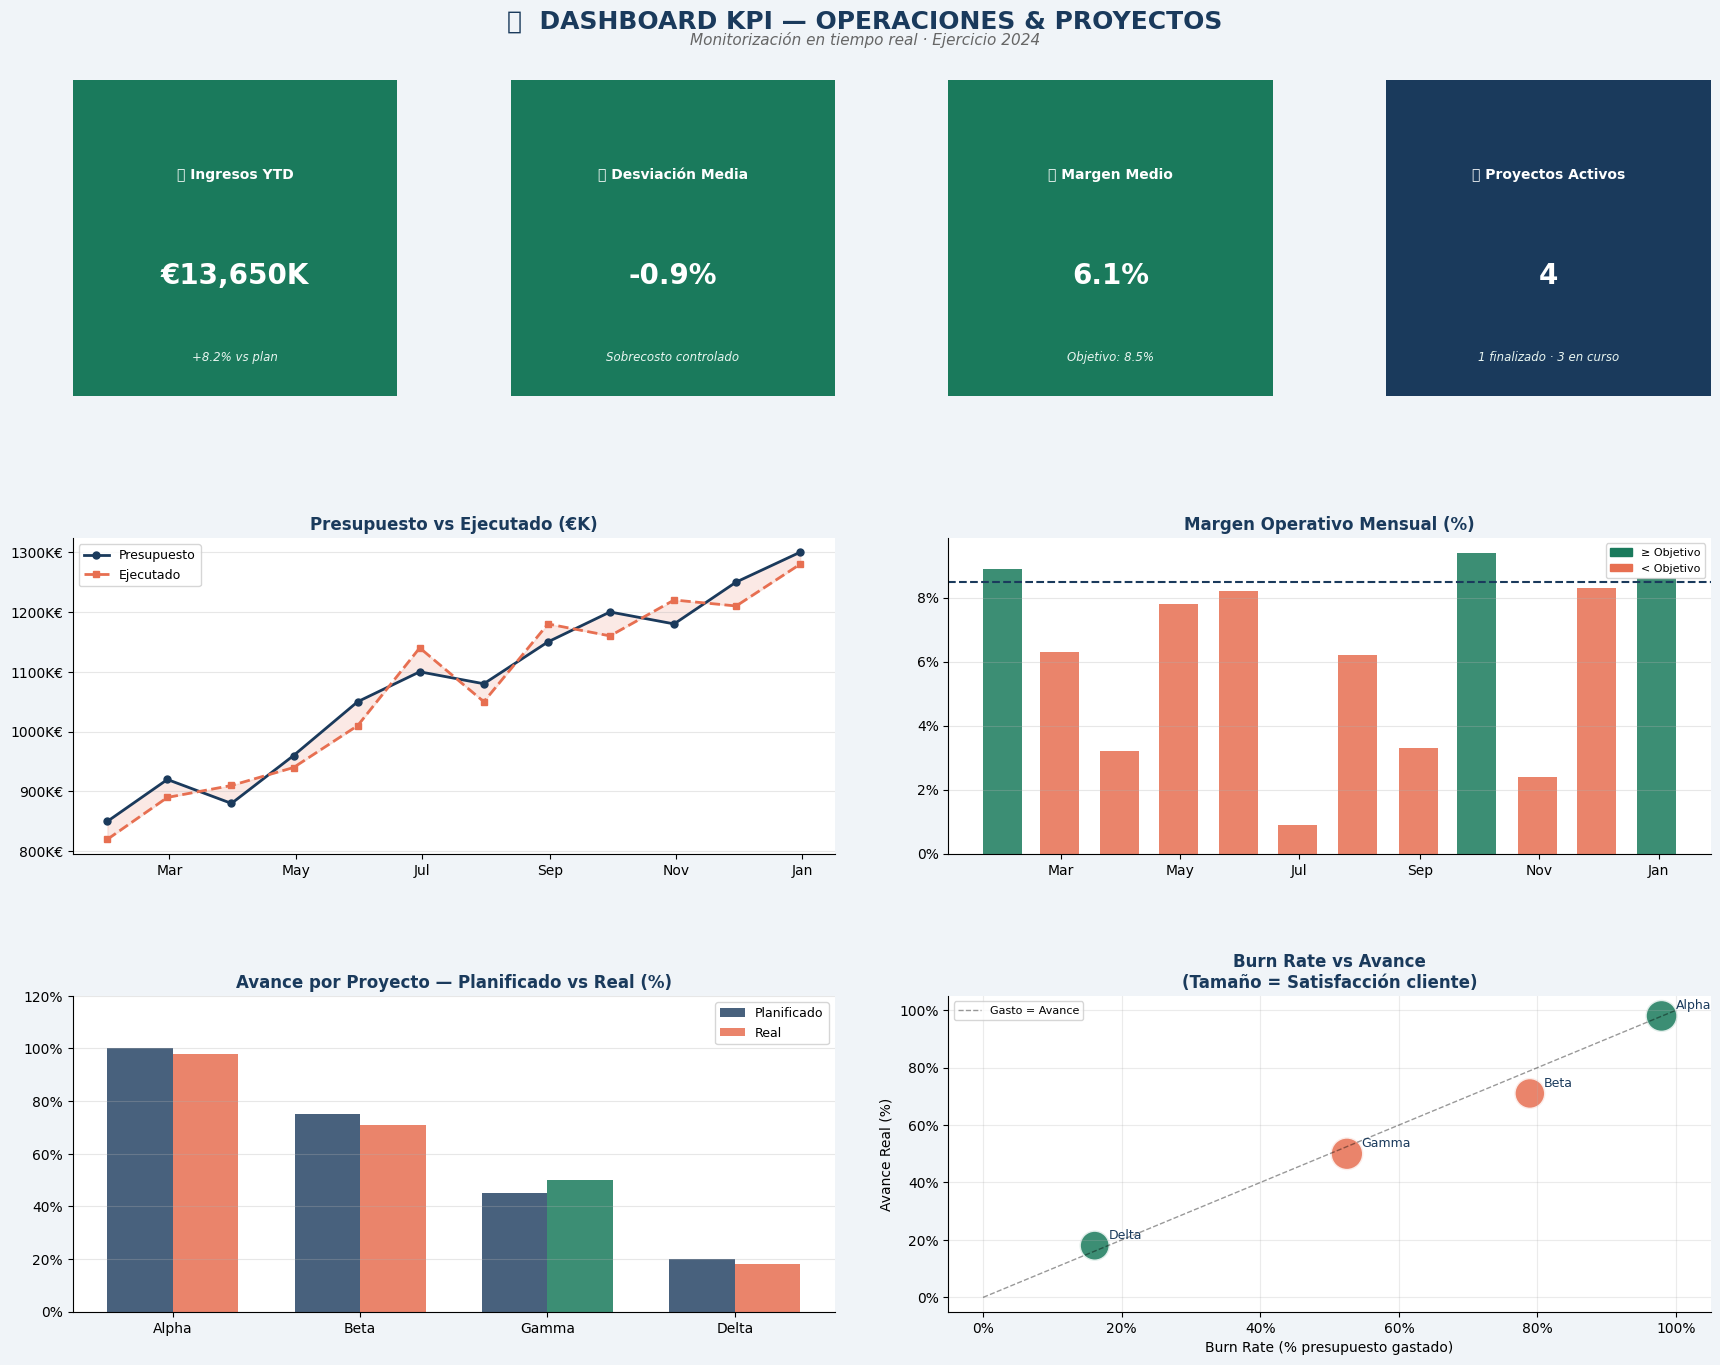

✅ Dashboard guardado en outputs/dashboard_kpi.png


In [3]:
fig = plt.figure(figsize=(18, 14), facecolor='#F0F4F8')
fig.suptitle('📊  DASHBOARD KPI — OPERACIONES & PROYECTOS',
             fontsize=18, fontweight='bold', color=C1, y=0.98)
fig.text(0.5, 0.955, 'Monitorización en tiempo real · Ejercicio 2024',
         ha='center', fontsize=11, color='#666', style='italic')

gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35,
              top=0.93, bottom=0.05, left=0.06, right=0.97)

# ── FILA 0: KPI Cards ──
kpi_data = [
    ('💰 Ingresos YTD', f'€{df_financiero["ingresos"].sum():,}K', '+8.2% vs plan', C2),
    ('📉 Desviación Media', f'{df_financiero["desviacion_pct"].mean():+.1f}%', 'Sobrecosto controlado', C3 if df_financiero["desviacion_pct"].mean()>1 else C2),
    ('📈 Margen Medio', f'{df_financiero["margen_real"].mean():.1f}%', f'Objetivo: {df_financiero["margen_objetivo"].mean():.1f}%', C2),
    ('🏗️ Proyectos Activos', '4', '1 finalizado · 3 en curso', C1),
]
for i, (titulo, valor, sub, color) in enumerate(kpi_data):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(color)
    ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
    ax_kpi.axis('off')
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0,0), 1, 1, boxstyle='round,pad=0.05',
                     facecolor=color, edgecolor='white', linewidth=2))
    ax_kpi.text(0.5, 0.70, titulo, ha='center', va='center', fontsize=10,
                color='white', fontweight='bold')
    ax_kpi.text(0.5, 0.38, valor, ha='center', va='center', fontsize=20,
                color='white', fontweight='bold')
    ax_kpi.text(0.5, 0.12, sub, ha='center', va='center', fontsize=8.5,
                color='rgba(255,255,255,0.85)' if False else '#e8f5f0',
                style='italic')

# ── FILA 1 izq: Evolución presupuesto vs ejecutado ──
ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(meses, df_financiero['presupuesto'], color=C1, lw=2, marker='o', ms=5, label='Presupuesto')
ax1.plot(meses, df_financiero['ejecutado'], color=C3, lw=2, marker='s', ms=5, linestyle='--', label='Ejecutado')
ax1.fill_between(meses, df_financiero['presupuesto'], df_financiero['ejecutado'],
                 alpha=0.15, color=C3)
ax1.set_title('Presupuesto vs Ejecutado (€K)', fontweight='bold', color=C1)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}K€'))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
ax1.legend(framealpha=0.8, fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── FILA 1 der: Margen mensual ──
ax2 = fig.add_subplot(gs[1, 2:])
colores_margen = [C2 if m >= 8.5 else C3 for m in df_financiero['margen_real']]
bars = ax2.bar(meses, df_financiero['margen_real'], color=colores_margen, alpha=0.85, width=20)
ax2.axhline(y=8.5, color=C1, linestyle='--', lw=1.5, label='Objetivo 8.5%')
ax2.set_title('Margen Operativo Mensual (%)', fontweight='bold', color=C1)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
verde_p = mpatches.Patch(color=C2, label='≥ Objetivo'); rojo_p = mpatches.Patch(color=C3, label='< Objetivo')
ax2.legend(handles=[verde_p, rojo_p], fontsize=8, framealpha=0.8)

# ── FILA 2 izq: Avance real vs planificado por proyecto ──
ax3 = fig.add_subplot(gs[2, :2])
x = np.arange(len(proyectos))
w = 0.35
ax3.bar(x - w/2, df_proyectos['avance_planificado'], w, label='Planificado', color=C1, alpha=0.8)
ax3.bar(x + w/2, df_proyectos['avance_real'], w, label='Real',
        color=[C2 if r>=p else C3 for r,p in zip(df_proyectos['avance_real'], df_proyectos['avance_planificado'])], alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels([p.split()[-1] for p in proyectos])
ax3.set_title('Avance por Proyecto — Planificado vs Real (%)', fontweight='bold', color=C1)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 120)

# ── FILA 2 der: Burn rate + satisfacción ──
ax4 = fig.add_subplot(gs[2, 2:])
colores_burn = [C2 if b <= a else C3 for b, a in zip(df_proyectos['burn_rate'], df_proyectos['avance_real'])]
scatter = ax4.scatter(df_proyectos['burn_rate'], df_proyectos['avance_real'],
                      s=df_proyectos['satisfaccion_cliente']*120,
                      c=colores_burn, alpha=0.85, edgecolors='white', linewidth=2)
for _, row in df_proyectos.iterrows():
    ax4.annotate(row['proyecto'].split()[-1], (row['burn_rate'], row['avance_real']),
                textcoords='offset points', xytext=(10,5), fontsize=9, color=C1)
ax4.plot([0,100],[0,100], 'k--', lw=1, alpha=0.4, label='Gasto = Avance')
ax4.set_xlabel('Burn Rate (% presupuesto gastado)'); ax4.set_ylabel('Avance Real (%)')
ax4.set_title('Burn Rate vs Avance\n(Tamaño = Satisfacción cliente)', fontweight='bold', color=C1)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax4.legend(fontsize=8); ax4.grid(alpha=0.25)

import os; os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/dashboard_kpi.png', dpi=150, bbox_inches='tight', facecolor='#F0F4F8')
plt.show()
print('✅ Dashboard guardado en outputs/dashboard_kpi.png')

## Conclusiones

### Alertas detectadas
- ⚠️ **Proyecto Beta**: burn rate del 79% con solo 71% de avance → riesgo de sobrecosto
- ⚠️ **Meses Jun y Ago**: ejecutado superó presupuesto en >3% → revisar control de costos
- ✅ **Proyecto Gamma**: mejor SPI (1.11) y mayor satisfacción del cliente (4.7)

### Recomendaciones
1. Activar protocolo de revisión de costos en Proyecto Beta
2. Replicar metodología de control de Proyecto Gamma en los demás proyectos
3. Establecer alertas automáticas cuando desviación presupuestaria supere el 2%